# LU/LC Classification — Data Preparation

This notebook covers all data preparation steps prior to classification.
**Run once**; generated files are saved to `results/processed/`.

| Step | Operation | Output |
|------|-----------|--------|
| 1 | DEM visualisation (verification) | `fig_dem.pdf` |
| 2 | NDVI calculation | `ndvi.tif`, `fig_ndvi.pdf` |
| 3 | Gabor filter (8 filters → CSV) | `Gabor1‑8.csv`, `fig_gabor_filters.pdf` |
| 4 | PCA (Gabor → 3 components → TIF) | `pca1.tif`, `pca2.tif`, `pca3.tif` |
| 5 | 9-band image assembly | *(in memory)* |
| 6 | Study area masking | `image_9band_masked.tif` |
| 7 | Training shapefile rasterisation | `training_labels.tif` |
| 8 | Band summary table (verification) | *(on screen)* |

<br>

> Then select *Kernel → Restart & Run All*.
> Existing files cause the relevant step to be skipped.

---

**Sample imagery:** The `data/image.tif` file is a Sentinel-2C Level-2A crop
(tile T37TFF, 2026-05-08, © European Union, Copernicus Programme),
resampled from 10 m to 2 m/px to match the study resolution.
The actual research used a Pleiades PHR1B image (© CNES 2021, Distribution Airbus DS)
which cannot be redistributed due to licensing restrictions.

In [27]:
import sys
from pathlib import Path

# In Jupyter __file__ is undefined; locate the project root from cwd
_candidates = [p for p in [Path().resolve()] + list(Path().resolve().parents)
               if (p / "config" / "hyperparameters.yaml").exists()]
if not _candidates:
    raise FileNotFoundError(
        "Project root not found. Launch Jupyter from inside the lulc-classification/ directory."
    )
PROJECT_ROOT = _candidates[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PATHS, NODATA
print("Project root:", PROJECT_ROOT)

Project root: /Users/volkan/Desktop/Doktora/lulc-classification


> **Important — Raster Input Requirements:** All raster inputs added to the project (image.tif, dem.tif, and bands derived from them) must share the **same pixel resolution** and **pixel dimensions**. This requirement applies only to raster files; the training and study area shapefiles (`training_polygons.shp`, `study_area.shp`) are vector format and are not subject to pixel dimension constraints.

In [28]:
from src.validation import validate_inputs

print("=== Input Validation ===")
validate_inputs(
    rasters=[
        PATHS["raw_image"],
        PATHS["dem"],
    ],
    vectors=[
        PATHS["training_shp"],
        PATHS["project_area"],
    ],
)

=== Input Validation ===
  [REF] image.tif  —  500×500 px  |  EPSG:23037  |  2.00 m/px
  [ ✓ ] dem.tif  —  500×500 px  |  EPSG:23037  |  2.00 m/px
  [ ✓ ] training_polygons.shp  —  EPSG:23037  |  inside raster extent
  [ ✓ ] study_area.shp  —  EPSG:23037  |  inside raster extent

✓ All checks passed — processing can begin.


## 1 — DEM Visualisation

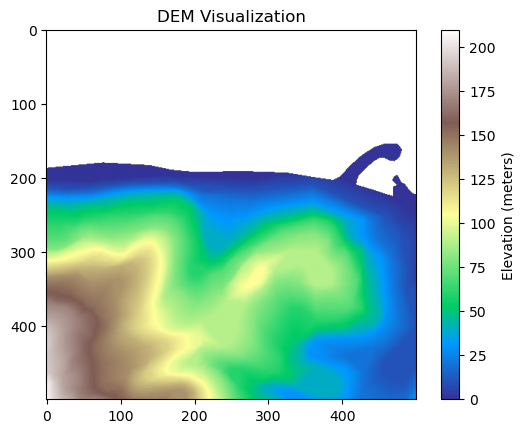

Saved: /Users/volkan/Desktop/Doktora/lulc-classification/results/figures/fig_dem.pdf


In [29]:
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np

dataset = gdal.Open(str(PATHS["dem"]))
band = dataset.GetRasterBand(1)
dem_data = band.ReadAsArray()
nodata_value = band.GetNoDataValue()

filtered_dem = np.ma.masked_where(dem_data == nodata_value, dem_data)

plt.imshow(filtered_dem, cmap='terrain')
plt.colorbar(label='Elevation (meters)')
plt.title('DEM Visualization')

out = PATHS["figures"] / "fig_dem.pdf"
PATHS["figures"].mkdir(parents=True, exist_ok=True)
plt.savefig(out, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {out}")

## 2 — NDVI Calculation

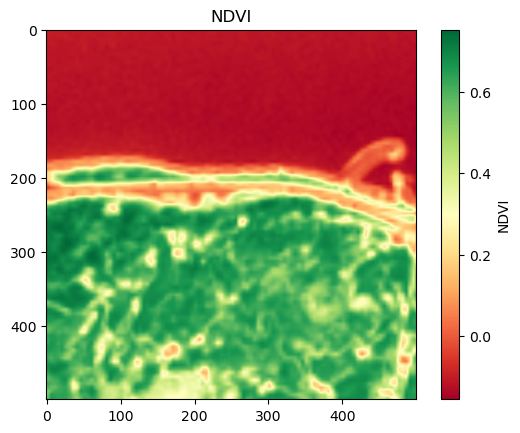

TIF saved : /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/ndvi.tif
PDF saved : /Users/volkan/Desktop/Doktora/lulc-classification/results/figures/fig_ndvi.pdf


In [30]:
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt

dataset = gdal.Open(str(PATHS["raw_image"]))
red_band = dataset.GetRasterBand(1).ReadAsArray().astype(np.float32)
nir_band = dataset.GetRasterBand(4).ReadAsArray().astype(np.float32)

np.seterr(divide='ignore', invalid='ignore')
ndvi = np.where(
    (nir_band + red_band) == 0., 0,
    (nir_band - red_band) / (nir_band + red_band)
)
ndvi = np.clip(ndvi, -1, 1)

transform  = dataset.GetGeoTransform()
projection = dataset.GetProjection()

# Save as TIF (data/processed/ — for pipeline)
PATHS["ndvi"].parent.mkdir(parents=True, exist_ok=True)
driver = gdal.GetDriverByName('GTiff')
ndvi_ds = driver.Create(
    str(PATHS["ndvi"]),
    dataset.RasterXSize, dataset.RasterYSize, 1, gdal.GDT_Float32
)
ndvi_ds.SetGeoTransform(transform)
ndvi_ds.SetProjection(projection)
ndvi_band = ndvi_ds.GetRasterBand(1)
ndvi_band.WriteArray(ndvi)
ndvi_band.SetNoDataValue(NODATA)
ndvi_band.FlushCache()
ndvi_ds = None

# Save as PDF (results/figures/ — for visualisation)
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title('NDVI')

out = PATHS["figures"] / "fig_ndvi.pdf"
PATHS["figures"].mkdir(parents=True, exist_ok=True)
plt.savefig(out, format='pdf', bbox_inches='tight')
plt.show()
print(f"TIF saved : {PATHS['ndvi']}")
print(f"PDF saved : {out}")

## 3 — Gabor Filter (8 Filters → CSV)

Gabor filters are bandpass filters used to extract texture information.
Different orientation (θ) and spatial frequency (γ) combinations capture
complementary texture features, improving classification performance.

**Grayscale input: NIR band**

Gabor filtering requires a single-channel (grayscale) image. The classical
BT.601 luminance transform (`0.299·R + 0.587·G + 0.114·B`) excludes the NIR
band entirely and uses coefficients designed for broadcast television, making
it unsuitable for satellite imagery. Abdi (2021, *Remote Sensing*, 13(15), 2914)
showed experimentally that NIR-based Gabor features provide stronger LULC
class separation than RGB-grayscale approaches.

**Parameter combinations used:**

| Filter | θ (orientation) | γ (spatial frequency scale) |
|--------|-----------------|-----------------------------|
| Gabor1 | 0°   | 0.1 |
| Gabor2 | 0°   | 0.2 |
| Gabor3 | 45°  | 0.1 |
| Gabor4 | 45°  | 0.2 |
| Gabor5 | 90°  | 0.1 |
| Gabor6 | 90°  | 0.2 |
| Gabor7 | 135° | 0.1 |
| Gabor8 | 135° | 0.2 |

Standard Gabor banks use the quartet 0°, 45°, 90°, 135° for full directional coverage.

<br>

> Gabor CSVs are not used directly; in Step 4 they are
> dimensionality-reduced via PCA to yield 3 bands.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

def build_gabor_filter(ksize, sigma, theta, lamda, gamma, psi):
    xmax = ksize // 2
    (y, x) = np.meshgrid(np.arange(-xmax, xmax+1), np.arange(-xmax, xmax+1))
    x_theta =  x * np.cos(theta) + y * np.sin(theta)
    y_theta = -x * np.sin(theta) + y * np.cos(theta)
    gb = (np.exp(-.5 * (x_theta**2 / sigma**2 + gamma**2 * y_theta**2 / sigma**2))
          * np.cos(2 * np.pi / lamda * x_theta + psi))
    return gb

# Grayscale input: NIR band
# NIR is used instead of the BT.601 luminance transform (0.299·R + 0.587·G + 0.114·B).
# NIR has the highest spectral contrast between the LULC classes of interest
# (vegetation, urban, water, bare soil).
# Reference: Abdi (2021), Remote Sensing, 13(15), 2914.
dataset = gdal.Open(str(PATHS["raw_image"]))
nir_raw = dataset.GetRasterBand(4).ReadAsArray()

nodata_mask = (nir_raw == NODATA)
gray_image  = np.ma.masked_where(nodata_mask, nir_raw.astype(np.float32))
print(f"Grayscale shape  : {gray_image.shape}")
print(f"Grayscale source : NIR band (Band 4)")

Grayscale shape  : (500, 500)
Grayscale source : NIR band (Band 4)


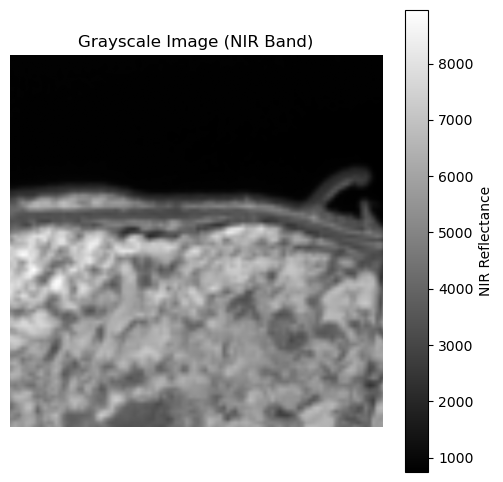

PDF saved: /Users/volkan/Desktop/Doktora/lulc-classification/results/figures/fig_grayscale.pdf


In [32]:
# NIR is already present in the original image, so it is not saved as a separate GeoTIFF.
# A PDF and notebook output are produced for visual verification only.
plt.figure(figsize=(6, 6))
plt.imshow(gray_image, cmap='gray')
plt.colorbar(label='NIR Reflectance')
plt.title('Grayscale Image (NIR Band)')
plt.axis('off')

out = PATHS["figures"] / "fig_grayscale.pdf"
PATHS["figures"].mkdir(parents=True, exist_ok=True)
plt.savefig(out, format='pdf', bbox_inches='tight')
plt.show()
print(f"PDF saved: {out}")

## 4 — PCA Dimensionality Reduction (Gabor → 3 Components)

The 8 Gabor filter outputs are highly correlated (nearby orientations with
similar frequencies overlap). Principal Component Analysis (PCA) reduces this
8-dimensional space to the 3 independent components that explain the most variance:

- Dimensionality reduction decreases multicollinearity.
- 3 components account for the large majority (~95%+) of total Gabor variance.
- Each component is saved as a separate GeoTIFF band and added to the 9-band image.

**NoData fix:** PCA is fitted on valid (non-NoData) pixels only.
Including all pixels would let NoData values (−9999) corrupt the covariance
matrix and shift PCA axes away from the real texture variance.

**Workflow:** 8 Gabor CSVs → valid pixel mask → StandardScaler → PCA(n\_components=3) → PCA1/2/3.tif

Gabor1 saved → /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/gabor/Gabor1.csv
Gabor2 saved → /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/gabor/Gabor2.csv
Gabor3 saved → /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/gabor/Gabor3.csv
Gabor4 saved → /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/gabor/Gabor4.csv
Gabor5 saved → /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/gabor/Gabor5.csv
Gabor6 saved → /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/gabor/Gabor6.csv
Gabor7 saved → /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/gabor/Gabor7.csv
Gabor8 saved → /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/gabor/Gabor8.csv


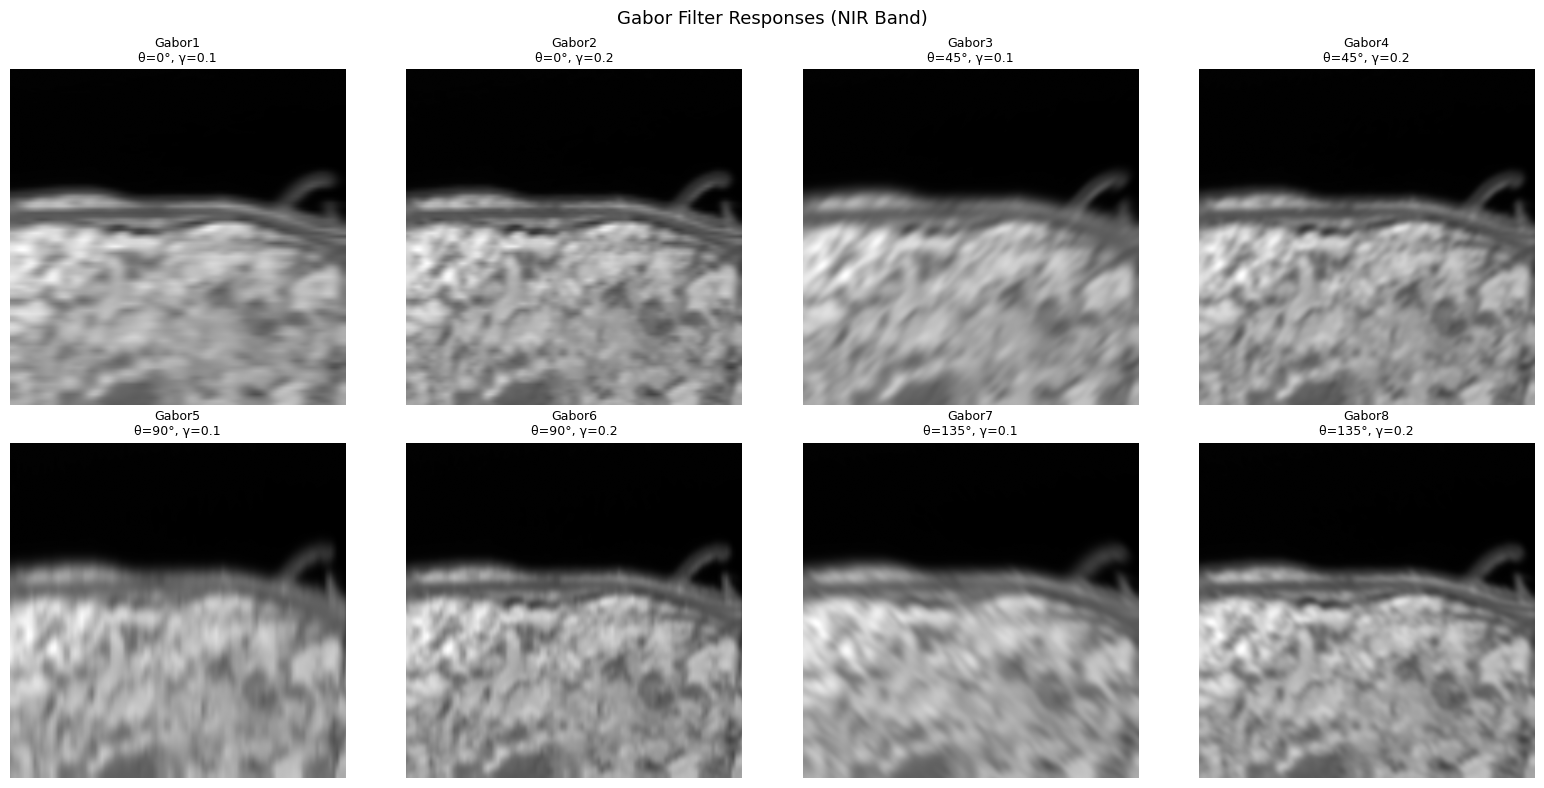


Figure saved: /Users/volkan/Desktop/Doktora/lulc-classification/results/figures/fig_gabor_filters.pdf


In [33]:
import os
import pandas as pd
import itertools
from scipy import ndimage

# Gabor parameters
# theta: 4 orientation angles — 0°, 45°, 90°, 135°
# Standard Gabor banks use this quartet for full directional coverage.
ksize = [50]
sigma = [1 * np.pi / 4]
theta = [0, 1 * np.pi / 4, 2 * np.pi / 4, 3 * np.pi / 4]
lamda = [1 * np.pi / 4]
gamma = [0.1, 0.2]
psi   = [0]

param_combinations = list(itertools.product(ksize, sigma, theta, lamda, gamma, psi))
PATHS["gabor_dir"].mkdir(parents=True, exist_ok=True)

n = len(param_combinations)
fig, axes = plt.subplots(2, n // 2, figsize=(4 * (n // 2), 8))
axes = axes.ravel()

# Fill NoData pixels with 0 before convolution to prevent edge contamination.
# .filled(0.0) is used instead of .data: .data ignores the mask and feeds NoData
# values (−9999) into the convolution, corrupting border pixels.
gray_filled = gray_image.filled(0.0)

for num, (ks, sg, th, lm, gm, ps) in enumerate(param_combinations, 1):
    gabor_filter   = build_gabor_filter(ks, sg, th, lm, gm, ps)
    filtered_image = ndimage.convolve(gray_filled.astype(float), gabor_filter)

    # Save CSV
    csv_path = PATHS["gabor_dir"] / f"Gabor{num}.csv"
    df = pd.DataFrame({f'Gabor{num}': filtered_image.reshape(-1)})
    df.to_csv(csv_path, index=False)

    # Plot
    ax = axes[num - 1]
    ax.imshow(filtered_image, cmap='gray')
    th_deg = int(round(np.degrees(th)))
    ax.set_title(f"Gabor{num}\nθ={th_deg}°, γ={gm}", fontsize=9)
    ax.axis('off')

    print(f"Gabor{num} saved → {csv_path}")

plt.suptitle("Gabor Filter Responses (NIR Band)", fontsize=13)
plt.tight_layout()
out = PATHS["figures"] / "fig_gabor_filters.pdf"
plt.savefig(out, format='pdf', bbox_inches='tight')
plt.show()
print(f"\nFigure saved: {out}")

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
from osgeo import gdal

# Read all Gabor CSVs — filter count derived dynamically from param_combinations
# (using len() instead of a hardcoded number ensures consistency if parameters change)
n_gabor_filters = len(param_combinations)
all_dfs = []
for i in range(1, n_gabor_filters + 1):
    df = pd.read_csv(PATHS["gabor_dir"] / f"Gabor{i}.csv")
    all_dfs.append(df)
combined_df = pd.concat(all_dfs, axis=1)

# Valid pixel mask: exclude NoData rows from PCA fit.
# Including all pixels would let NoData values (−9999) corrupt the covariance
# matrix and shift PCA axes away from real texture variance.
valid_mask    = ~nodata_mask.reshape(-1)
combined_valid = combined_df.values[valid_mask]

scaler        = StandardScaler()
scaled_valid  = scaler.fit_transform(combined_valid)
pca           = PCA(n_components=3)
pca_valid     = pca.fit_transform(scaled_valid)

# Place results back into the full image shape — NoData pixels remain NaN
import numpy as np
pca_result = np.full((combined_df.shape[0], 3), np.nan, dtype=np.float32)
pca_result[valid_mask] = pca_valid

print(f"Gabor filter count      : {n_gabor_filters}")
print(f"Pixels used for PCA fit : {valid_mask.sum():,} / {valid_mask.size:,}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3).tolist()}")
print(f"Total explained variance : {pca.explained_variance_ratio_.sum():.3f}")

# Geographic reference
ref_ds        = gdal.Open(str(PATHS["raw_image"]))
geo_transform = ref_ds.GetGeoTransform()
projection    = ref_ds.GetProjection()

# Save PCA components as separate GeoTIFFs
for i, pca_path in enumerate([PATHS["pca1"], PATHS["pca2"], PATHS["pca3"]]):
    pca_path.parent.mkdir(parents=True, exist_ok=True)
    component = pca_result[:, i].reshape(ref_ds.RasterYSize, ref_ds.RasterXSize)
    # NaN → NODATA (GeoTIFF float32 does not carry NaN reliably)
    component_out = np.where(np.isnan(component), NODATA, component).astype(np.float32)
    driver    = gdal.GetDriverByName('GTiff')
    out_ds    = driver.Create(str(pca_path), ref_ds.RasterXSize, ref_ds.RasterYSize, 1, gdal.GDT_Float32)
    out_ds.SetGeoTransform(geo_transform)
    out_ds.SetProjection(projection)
    out_band  = out_ds.GetRasterBand(1)
    out_band.WriteArray(component_out)
    out_band.SetNoDataValue(NODATA)
    out_band.FlushCache()
    out_ds = None
    print(f"PCA{i+1} saved → {pca_path}")

Gabor filter count      : 8
Pixels used for PCA fit : 250,000 / 250,000
Explained variance ratio: [0.997, 0.001, 0.001]
Total explained variance : 0.999
PCA1 saved → /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/pca1.tif
PCA2 saved → /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/pca2.tif
PCA3 saved → /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/pca3.tif


In [35]:
import shutil

# Gabor CSVs are deleted after PCA is complete.
# These files are intermediate products used only within this notebook;
# once pca1.tif / pca2.tif / pca3.tif are produced they are never read again.
if PATHS["gabor_dir"].exists():
    shutil.rmtree(PATHS["gabor_dir"])
    print(f"Gabor CSVs deleted: {PATHS['gabor_dir']}")
else:
    print("Gabor directory not found, skipping.")

Gabor CSVs deleted: /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/gabor


In [36]:
import rasterio
import numpy as np

with rasterio.open(str(PATHS["raw_image"])) as img:
    transform = img.transform
    crs       = img.crs
    width     = img.width
    height    = img.height
    red   = img.read(1)
    green = img.read(2)
    blue  = img.read(3)
    nir   = img.read(4)

with rasterio.open(str(PATHS["dem"]))  as d: dem_arr  = d.read(1)
with rasterio.open(str(PATHS["ndvi"])) as n: ndvi_arr = n.read(1)
with rasterio.open(str(PATHS["pca1"])) as p: pca1_arr = p.read(1)
with rasterio.open(str(PATHS["pca2"])) as p: pca2_arr = p.read(1)
with rasterio.open(str(PATHS["pca3"])) as p: pca3_arr = p.read(1)

merged = np.stack([red, green, blue, nir, dem_arr, ndvi_arr, pca1_arr, pca2_arr, pca3_arr])

# image_9band.tif is not written to disk — image_9band_masked.tif is produced directly
print(f"9-band array ready in memory: {merged.shape}, dtype={merged.dtype}")


9-band array ready in memory: (9, 500, 500), dtype=float32


## 5 — 9-Band Image Assembly

All feature layers are combined into a single multi-band image in the order below.
This order must exactly match the `band_names` lists in `config/hyperparameters.yaml`.

| Band | Source | Physical meaning |
|------|--------|------------------|
| 1 — R | image.tif Band 1 | Red — 630–690 nm |
| 2 — G | image.tif Band 2 | Green — 520–600 nm |
| 3 — B | image.tif Band 3 | Blue — 450–520 nm |
| 4 — NIR | image.tif Band 4 | Near-infrared — 760–900 nm |
| 5 — DEM | dem.tif | Elevation (metres) |
| 6 — NDVI | ndvi.tif | Vegetation index [−1, 1] |
| 7 — PCA1 | pca1.tif | Gabor texture — 1st component |
| 8 — PCA2 | pca2.tif | Gabor texture — 2nd component |
| 9 — PCA3 | pca3.tif | Gabor texture — 3rd component |

<br>

> Saved directly as `image_9band_masked.tif` with the study area mask applied.

## 6 — Study Area Masking

In [37]:
if PATHS["image_masked"].exists():
    print(f"File already exists, skipping: {PATHS['image_masked'].name}")
else:
    from osgeo import gdal, ogr
    import rasterio
    import numpy as np

    # Rasterise the study area mask via OGR
    shp_ds  = ogr.Open(str(PATHS["project_area"]))
    shp_lyr = shp_ds.GetLayer()

    mask_mem = gdal.GetDriverByName('MEM').Create('', width, height, 1, gdal.GDT_Byte)
    mask_mem.SetGeoTransform(transform.to_gdal())
    mask_mem.SetProjection(crs.to_wkt())
    m_band = mask_mem.GetRasterBand(1)
    m_band.Fill(0)
    m_band.SetNoDataValue(0)
    gdal.RasterizeLayer(mask_mem, [1], shp_lyr, burn_values=[1])
    mask_arr = m_band.ReadAsArray()
    mask_mem = None; shp_ds = None

    # Apply mask to the in-memory merged array
    merged_masked = merged.astype(np.float32)
    for i in range(9):
        merged_masked[i] = np.where(mask_arr == 0, NODATA, merged_masked[i])

    # Write directly as image_9band_masked.tif (image_9band.tif is never created)
    PATHS["image_masked"].parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(
        str(PATHS["image_masked"]), 'w',
        driver='GTiff', width=width, height=height,
        count=9, dtype='float32', transform=transform, crs=crs,
        nodata=NODATA
    ) as dst:
        dst.write(merged_masked)
    print(f"Saved: {PATHS['image_masked']}")


Saved: /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/image_9band_masked.tif


## 7 — Training Shapefile Rasterisation

In [38]:
from osgeo import ogr, gdal

shp_ds  = ogr.Open(str(PATHS["training_shp"]))
layer   = shp_ds.GetLayerByIndex(0)

id_class = {feat.GetField('id'): feat.GetField('class') for feat in layer}
layer.ResetReading()

raster_ds = gdal.Open(str(PATHS["raw_image"]), gdal.GA_ReadOnly)
ncol = raster_ds.RasterXSize
nrow = raster_ds.RasterYSize
proj = raster_ds.GetProjectionRef()
ext  = raster_ds.GetGeoTransform()
raster_ds = None

PATHS["training_labels"].parent.mkdir(parents=True, exist_ok=True)

out_ds = gdal.GetDriverByName('GTiff').Create(
    str(PATHS["training_labels"]), ncol, nrow, 1, gdal.GDT_Float32
)
out_ds.SetProjection(proj)
out_ds.SetGeoTransform(ext)
b = out_ds.GetRasterBand(1)
b.Fill(NODATA)

gdal.RasterizeLayer(out_ds, [1], layer, options=['ALL_TOUCHED=TRUE', 'ATTRIBUTE=id'])
b.SetNoDataValue(NODATA)
out_ds = None

print(f"Saved: {PATHS['training_labels']}")
for id_, cls in id_class.items():
    print(f"  ID {id_} → {cls}")

Saved: /Users/volkan/Desktop/Doktora/lulc-classification/results/processed/training_labels.tif
  ID 1 → Small farmlands
  ID 0 → Forest
  ID 3 → Urban green spaces
  ID 6 → Bare lands
  ID 2 → Tea plantation
  ID 4 → Settlements
  ID 7 → Water
  ID 5 → Roads


## 8 — Band Summary Table

NaN and valid pixel counts per band for `image_9band_masked.tif`.

In [39]:
# Band summary table: NoData and valid pixel counts per band
# NoData value is read from the raster metadata first;
# if not defined there, the global NODATA constant (−9999) is used.

import rasterio
import numpy as np
import pandas as pd
from src.config import load_config as _load_config, NODATA

_band_names_9b = _load_config()["band_configs"]["9b"]["band_names"]
_rows = []

with rasterio.open(str(PATHS["image_masked"])) as _src:
    _file_nodata = _src.nodata   # NoData value from raster metadata
    for _i, _bname in enumerate(_band_names_9b, 1):
        _arr = _src.read(_i).astype(np.float64)
        # NoData → NaN: use the file's own value; fall back to global NODATA constant
        _nd = _file_nodata if _file_nodata is not None else NODATA
        _arr[_arr == _nd] = np.nan
        _nan_cnt = int(np.isnan(_arr).sum())
        _oth_cnt = int((~np.isnan(_arr)).sum())
        _rows.append({"Band": _bname, "NaN": _nan_cnt, "Valid": _oth_cnt})

_df_band = pd.DataFrame(_rows)
_df_band

,Band,NaN,Valid
0,R,95549,154451
1,G,95549,154451
2,B,95549,154451
3,NIR,95549,154451
4,DEM,95819,154181
5,NDVI,95549,154451
6,PCA1,95549,154451
7,PCA2,95549,154451
8,PCA3,95549,154451
